<a href="https://colab.research.google.com/github/Swathi04705/Applied-Machine-Learning-Lab/blob/main/linearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

python example: simple linear regression


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
#input study hours

x= np.array([1,2,3,4,5]).reshape(-1,1)
x

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [ ]:
#output marks
y = np.array([40,50,50,60,70])
y

array([40, 50, 50, 60, 70])

In [ ]:

#create and train the model
model = LinearRegression()
model.fit(x,y)

LinearRegression()

In [ ]:
#display the regression parameters
print("intercept:",model.intercept_)
print("slope:",model.coef_[0])

intercept: 33.0
slope: 7.0


In [ ]:
#predict marks for six study hours
new_data = np.array([[6]])
new_marks = model.predict(new_data)

In [ ]:
print("predicted marks:",new_marks[0])

predicted marks: 75.0


In [ ]:

#prediction for the original observations
y_pred = model.predict(x)
y_pred

array([40., 47., 54., 61., 68.])

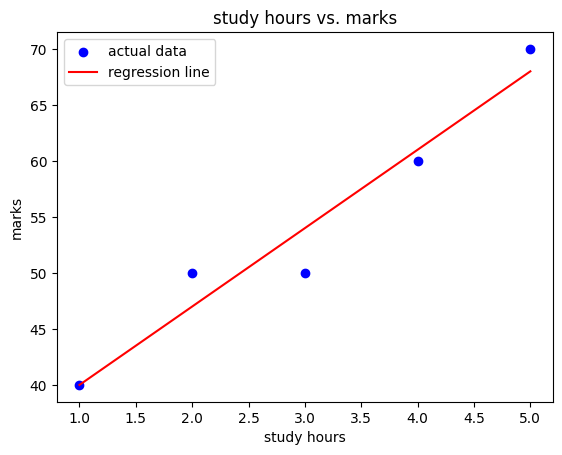

In [ ]:
#plot data and regression line
plt.scatter(x,y,color='blue',label='actual data')
plt.plot(x,y_pred,color='red',label='regression line')
plt.xlabel('study hours')
plt.ylabel('marks')
plt.title('study hours vs. marks')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
mae = mean_absolute_error(y,y_pred)
mse = mean_squared_error(y,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y,y_pred)

In [ ]:
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 2.0
MSE: 6.0
RMSE: 2.449489742783178
R2: 0.9423076923076923


# tarin - test split example

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


In [ ]:
data = {
    "study hours":[1,2,3,4,5,6,7,8,9,10],
    "marks":[32,38,43,50,54,61,68,73,81,88]
}

In [ ]:
df = pd.DataFrame(data)
df

,study hours,marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


In [ ]:
X = df[['study hours']]
y = df['marks']

In [ ]:
X

,study hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [ ]:
y

,marks
0,32
1,38
2,43
3,50
4,54
5,61
6,68
7,73
8,81
9,88


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [ ]:
print("intercept:", model.intercept_)
print("slope:", model.coef_[0])
print("actual values:", y_test.values)
print("predicted values:", y_pred)

intercept: 24.724137931034484
slope: 6.163793103448276
actual values: [81 38]
predicted values: [80.19827586 37.05172414]


In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.875
MSE: 0.7709943519619504
RMSE: 0.8780628405541089
R2: 0.9983320836085193


# multiple linear regerssion in python

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

data = {
    "study_hours":[2,3,4,5,6,7,8,9],
    "study_hours/week":[14,21,28,35,42,49,56,63],
    "attendence":[60,65,70,75,80,85,90,95],
    "assignment_score":[50,55,58,65,70,74,80,88],
    "Final_marks":[42,48,54,61,67,73,81,89]
}

In [ ]:
df = pd.DataFrame(data)
df

,study_hours,study_hours/week,attendence,assignment_score,Final_marks
0,2,14,60,50,42
1,3,21,65,55,48
2,4,28,70,58,54
3,5,35,75,65,61
4,6,42,80,70,67
5,7,49,85,74,73
6,8,56,90,80,81
7,9,63,95,88,89


In [ ]:
X = df[["study_hours","study_hours/week","attendence","assignment_score"]]
y = df["Final_marks"]
X

,study_hours,study_hours/week,attendence,assignment_score
0,2,14,60,50
1,3,21,65,55
2,4,28,70,58
3,5,35,75,65
4,6,42,80,70
5,7,49,85,74
6,8,56,90,80
7,9,63,95,88


In [ ]:
y

,Final_marks
0,42
1,48
2,54
3,61
4,67
5,73
6,81
7,89


In [ ]:

model = LinearRegression()
model.fit(X,y)
print("Intercept:", model.intercept_)

Intercept: -6.852852852852834


In [ ]:
coefficient_table = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

In [ ]:
print(coefficient_table)

            Feature  Coefficient
0       study_hours     0.045556
1  study_hours/week     0.318889
2        attendence     0.227778
3  assignment_score     0.608108


In [ ]:
new_student = pd.DataFrame({
    "study_hours":[6],
    "study_hours/week":[35],
    "attendence":[82],
    "assignment_score":[75]
})

In [ ]:
prediction = model.predict(new_student)
print("Predicted Final Marks:",prediction[0])

Predicted Final Marks: 68.86747747747748


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.to_csv("drive/My Drive/Colab Notebooks/datasets/students.csv",index=False)

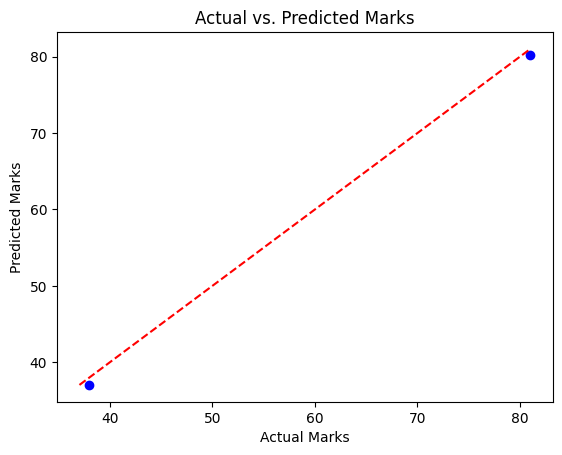

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred, color= "blue")
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], color = "red", linestyle="--")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs. Predicted Marks")
plt.show()


# residual plot

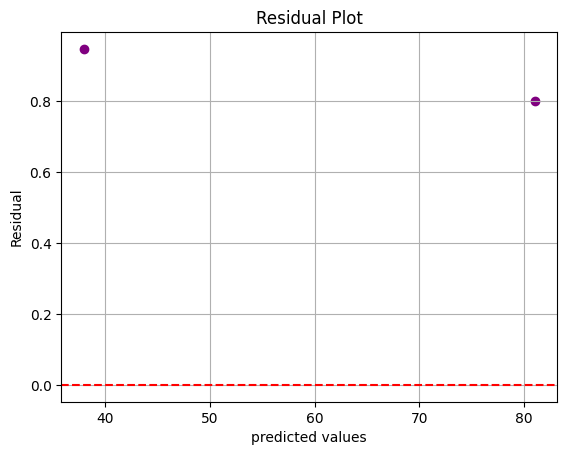

In [ ]:
residual = y_test - y_pred
plt.scatter(y_test, residual, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("predicted values")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

data = {
    "size":[800,1000,1200,1500,1800],
    "Location":["Rural", "Urban","Rural","Urban","Urban"],
    "Price":[30,50,42,72,85]
}

df = pd.DataFrame(data)

df_encoded = pd.get_dummies(df,
                            columns=["Location"],
                            drop_first=True,
                            dtype=int)

df_encoded

,size,Price,Location_Urban
0,800,30,0
1,1000,50,1
2,1200,42,0
3,1500,72,1
4,1800,85,1
